In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.visualization import ZScaleInterval
import glob

## load image data (Q1)

save all bias fits files to list `bias_files`

In [16]:
bias_files = glob.glob('drive/MyDrive/astro465/lab2/bias_images_20250928/*Bias*.fits')
bias_files

['drive/MyDrive/astro465/lab2/bias_images_20250928/20250928_030914313_Bias_0_00001s_2x2.fits',
 'drive/MyDrive/astro465/lab2/bias_images_20250928/20250928_030918779_Bias_0_00001s_2x2.fits',
 'drive/MyDrive/astro465/lab2/bias_images_20250928/20250928_030923255_Bias_0_00001s_2x2.fits',
 'drive/MyDrive/astro465/lab2/bias_images_20250928/20250928_030927733_Bias_0_00001s_2x2.fits',
 'drive/MyDrive/astro465/lab2/bias_images_20250928/20250928_030932215_Bias_0_00001s_2x2.fits',
 'drive/MyDrive/astro465/lab2/bias_images_20250928/20250928_030936678_Bias_0_00001s_2x2.fits',
 'drive/MyDrive/astro465/lab2/bias_images_20250928/20250928_030941162_Bias_0_00001s_2x2.fits',
 'drive/MyDrive/astro465/lab2/bias_images_20250928/20250928_030945643_Bias_0_00001s_2x2.fits',
 'drive/MyDrive/astro465/lab2/bias_images_20250928/20250928_030950113_Bias_0_00001s_2x2.fits',
 'drive/MyDrive/astro465/lab2/bias_images_20250928/20250928_030954598_Bias_0_00001s_2x2.fits',
 'drive/MyDrive/astro465/lab2/bias_images_20250928

save all flat fits files to list `flat_files`

In [93]:
flat_files = glob.glob('drive/MyDrive/astro465/lab2/data2/*Flat*.fits')
flat_files

['drive/MyDrive/astro465/lab2/data2/20250925_203844690_Flat_r_0_1s_2x2.fits',
 'drive/MyDrive/astro465/lab2/data2/20250925_204031509_Flat_r_0_2s_2x2.fits',
 'drive/MyDrive/astro465/lab2/data2/20250925_204111419_Flat_r_0_5s_2x2.fits',
 'drive/MyDrive/astro465/lab2/data2/20250925_204140_Flat_r_1s_2x2.fits',
 'drive/MyDrive/astro465/lab2/data2/20250925_204156_Flat_r_1_5s_2x2.fits',
 'drive/MyDrive/astro465/lab2/data2/20250925_204208_Flat_r_2s_2x2.fits',
 'drive/MyDrive/astro465/lab2/data2/20250925_204220_Flat_r_2_5s_2x2.fits',
 'drive/MyDrive/astro465/lab2/data2/20250925_204232_Flat_r_3s_2x2.fits',
 'drive/MyDrive/astro465/lab2/data2/20250925_204247_Flat_r_3_5s_2x2.fits',
 'drive/MyDrive/astro465/lab2/data2/20250925_204300_Flat_r_4s_2x2.fits',
 'drive/MyDrive/astro465/lab2/data2/20250925_204416_Flat_g_3s_2x2.fits',
 'drive/MyDrive/astro465/lab2/data2/20250925_204452_Flat_g_6s_2x2.fits',
 'drive/MyDrive/astro465/lab2/data2/20250925_204518_Flat_g_10s_2x2.fits',
 'drive/MyDrive/astro465/lab2

reading in flat-field pairs (Dr. McConnell's)

In [18]:
flat_pairs_files = glob.glob('drive/MyDrive/astro465/lab2/optical_flatfield_pairs/*Flat*.fits')
flat_pairs_files

['drive/MyDrive/astro465/lab2/optical_flatfield_pairs/20250825_204837_Flat_g_5s_2x2.fits',
 'drive/MyDrive/astro465/lab2/optical_flatfield_pairs/20250825_204641_Flat_g_1s_2x2.fits',
 'drive/MyDrive/astro465/lab2/optical_flatfield_pairs/20250825_204636_Flat_g_1s_2x2.fits',
 'drive/MyDrive/astro465/lab2/optical_flatfield_pairs/20250825_204734_Flat_g_2s_2x2.fits',
 'drive/MyDrive/astro465/lab2/optical_flatfield_pairs/20250825_204827_Flat_g_5s_2x2.fits',
 'drive/MyDrive/astro465/lab2/optical_flatfield_pairs/20250825_204740_Flat_g_2s_2x2.fits',
 'drive/MyDrive/astro465/lab2/optical_flatfield_pairs/20250825_204942_Flat_g_10s_2x2.fits',
 'drive/MyDrive/astro465/lab2/optical_flatfield_pairs/20250825_204956_Flat_g_10s_2x2.fits',
 'drive/MyDrive/astro465/lab2/optical_flatfield_pairs/20250825_205200_Flat_g_20s_2x2.fits',
 'drive/MyDrive/astro465/lab2/optical_flatfield_pairs/20250825_205225_Flat_g_20s_2x2.fits',
 'drive/MyDrive/astro465/lab2/optical_flatfield_pairs/20250825_210433_Flat_r_1s_2x2.fi

In [19]:
flats_pairs = []

for f in flat_pairs_files:
    flat_fit=fits.open(f)
    flat=flat_fit[0].data.astype('float')
    flats_pairs.append(flat)

flats_pairs = np.array(flats_pairs)
flats_pairs.shape

(34, 1252, 1663)

preview the first bias file in list

In [20]:
bias_fit = fits.open(bias_files[0])
bias_fit.info()

Filename: drive/MyDrive/astro465/lab2/bias_images_20250928/20250928_030914313_Bias_0_00001s_2x2.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      51   (1663, 1252)   int16 (rescales to uint16)   


In [21]:
bias_fit[0].header

SIMPLE  =                    T / file does conform to FITS standard             
BITPIX  =                   16 / number of bits per data pixel                  
NAXIS   =                    2 / number of data axes                            
NAXIS1  =                 1663 / length of data axis 1                          
NAXIS2  =                 1252 / length of data axis 2                          
EXTEND  =                    T / FITS dataset may contain extensions            
COMMENT   FITS (Flexible Image Transport System) format is defined in 'Astronomy
COMMENT   and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H 
BZERO   =                32768 / offset data range to that of unsigned short    
BSCALE  =                    1 / default scaling factor                         
ROWORDER= 'TOP-DOWN'           / Order of the rows in image array               
INSTRUME= 'Apogee F8300 CCD'   / Instrument used for acquisition                
TELESCOP= 'Linda Sue 16-inch

preview the first flat file in pairs list

In [22]:
flat_fit = fits.open(flat_pairs_files[0])
flat_fit.info()

Filename: drive/MyDrive/astro465/lab2/optical_flatfield_pairs/20250825_204837_Flat_g_5s_2x2.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      51   (1663, 1252)   int16 (rescales to uint16)   


In [23]:
flat_fit[0].header

SIMPLE  =                    T / file does conform to FITS standard             
BITPIX  =                   16 / number of bits per data pixel                  
NAXIS   =                    2 / number of data axes                            
NAXIS1  =                 1663 / length of data axis 1                          
NAXIS2  =                 1252 / length of data axis 2                          
EXTEND  =                    T / FITS dataset may contain extensions            
COMMENT   FITS (Flexible Image Transport System) format is defined in 'Astronomy
COMMENT   and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H 
BZERO   =                32768 / offset data range to that of unsigned short    
BSCALE  =                    1 / default scaling factor                         
ROWORDER= 'TOP-DOWN'           / Order of the rows in image array               
INSTRUME= 'Apogee F8300 CCD'   / Instrument used for acquisition                
TELESCOP= 'Linda Sue 16-inch

### Q1.
Open each image in your jupyter notebook. To avoid issues with the raw data, convert all integer values to "regular" numbers.

In [24]:
biases = []

for f in bias_files:
    bias_fit=fits.open(f)
    bias=bias_fit[0].data.astype('float')
    biases.append(bias)

biases = np.array(biases)
biases.shape

(11, 1252, 1663)

In [95]:
flats = []

for f in flat_files:
    flat_fit=fits.open(f)
    flat=flat_fit[0].data.astype('float')
    flats.append(flat)

flats = np.array(flats)
flats.shape

(48, 1252, 1663)

In [25]:
flats_pairs = []

for f in flat_pairs_files:
    flat_fit=fits.open(f)
    flat=flat_fit[0].data.astype('float')
    flats_pairs.append(flat)

flats_pairs = np.array(flats_pairs)
flats_pairs.shape

(34, 1252, 1663)

calculate vmin and vmax for plotting

In [26]:
zscale = ZScaleInterval()
vmin_b, vmax_b = zscale.get_limits(biases.flatten())
vmin_b, vmax_b

(np.float64(1313.0), np.float64(1407.0))

plot all 11 bias frames

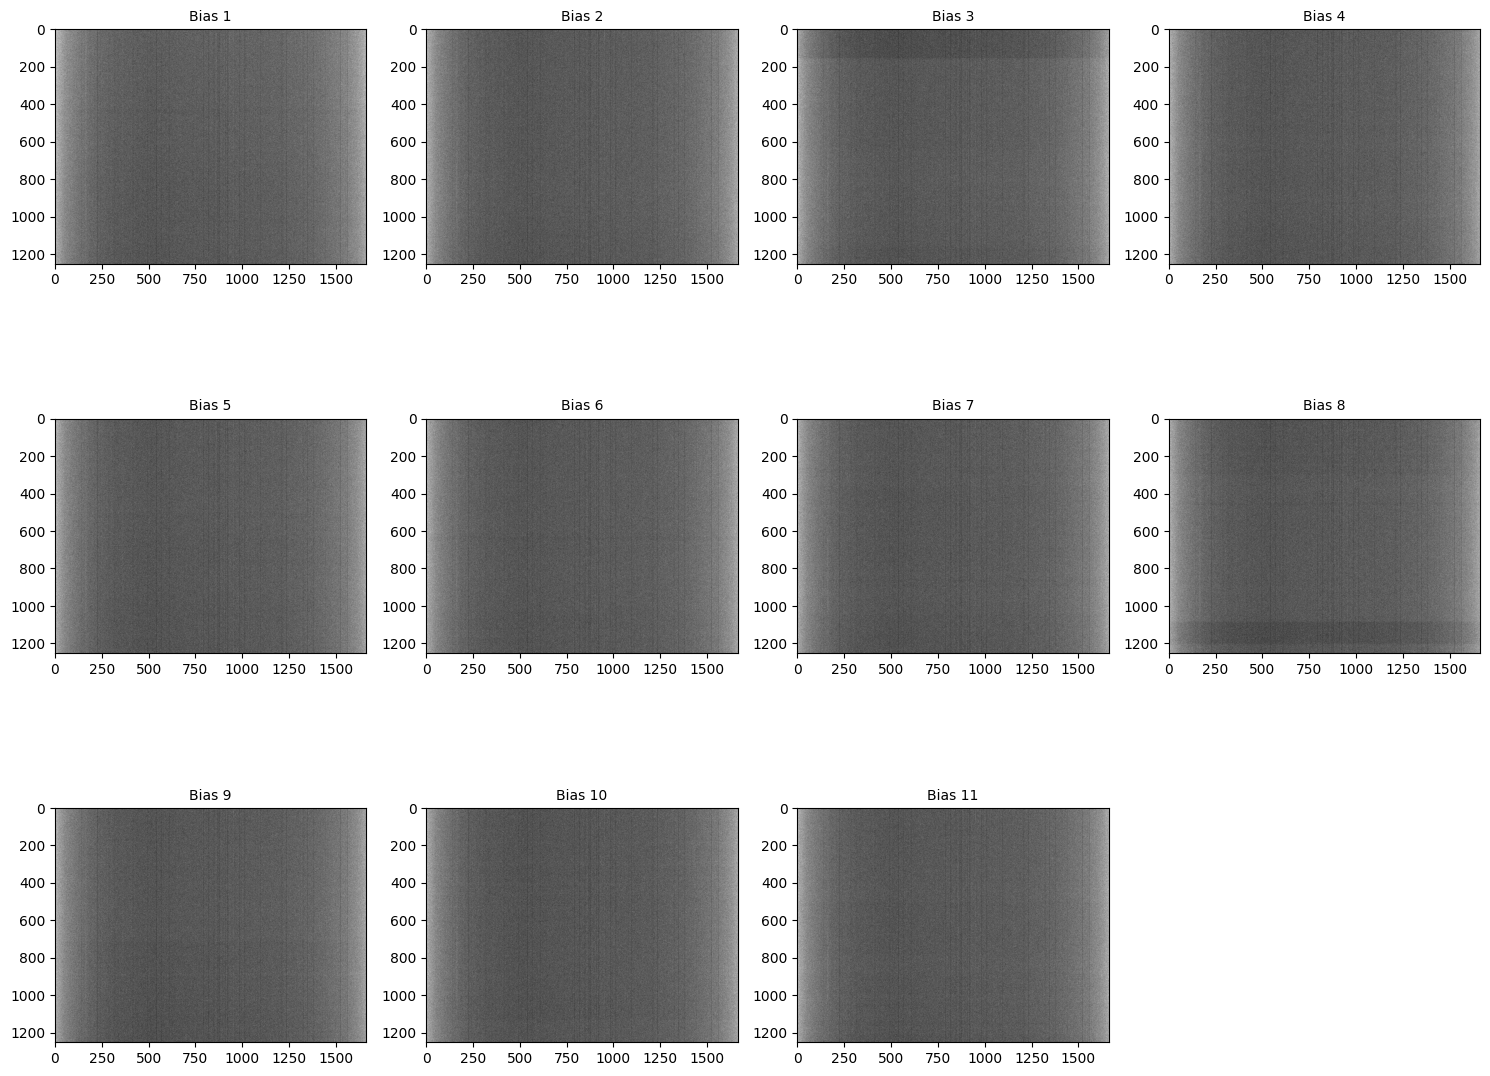

In [27]:
fig, axes = plt.subplots(3, 4, figsize=(15, 12))
axes = axes.flatten()

for i, bias_data in enumerate(biases):
    ax = axes[i]
    im = ax.imshow(bias_data, vmin=vmin_b, vmax=vmax_b, cmap='gray')

    ax.set_title(f'Bias {i + 1}', fontsize=10)

for j in range(11, 12):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## measure CCD's bias level and read noise (Q2)

### Q2.

From your set of bias images, derive the detector's bias signal $\bar{B}$ and readnoise $RN = \sigma_B$

In [28]:
avg_bias = np.mean(biases.flatten())
avg_bias

np.float64(1350.0236025355114)

In [29]:
rn = np.std(biases.flatten())
rn

np.float64(12.762877533642653)

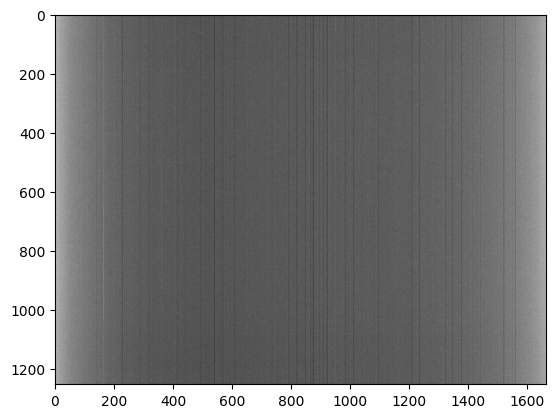

In [30]:
plt.imshow(np.mean(biases, axis=0), vmin=vmin_b, vmax=vmax_b, cmap='gray')

In [31]:
# plt.hist(biases.flatten(), bins=100)

## calculate gain setting (Q3-Q5)

### Q3.

For each pair of flat-fields (identical filter & exposure time), calculate the average intensity level in each image ($\bar{F_1}, \bar{F_2}$) and the noise of the difference image ($\sigma_{\Delta F}$ where $\Delta F = F_1 - F_2$)

#### optical flatfield pairs

isolating flats indices with 'i' filter

In [32]:
index = [i for i, filepath in enumerate(flat_pairs_files) if 'Flat_i' in filepath]
index

[20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33]

##### i, 0.25s

In [33]:
index = [i for i, filepath in enumerate(flat_pairs_files) if 'Flat_i_0_25s' in filepath]
index

[32, 33]

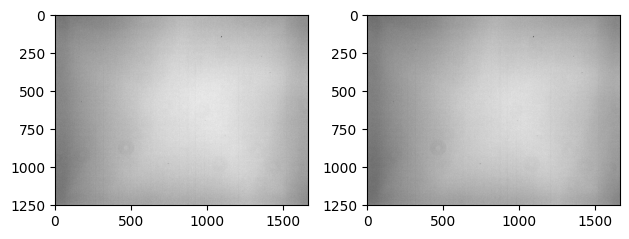

In [34]:
vmin_32, vmax_32 = zscale.get_limits(flats_pairs[32].flatten())
vmin_33, vmax_33 = zscale.get_limits(flats_pairs[33].flatten())

fig, (ax1,ax2) = plt.subplots(1,2)

ax1.imshow(flats_pairs[32], vmin=vmin_32, vmax=vmax_32, cmap='gray')
ax2.imshow(flats_pairs[33], vmin=vmin_33, vmax=vmax_33, cmap='gray')

plt.tight_layout()
plt.show()

In [35]:
# intensity
avg_32 = np.mean(flats_pairs[32])
avg_33 = np.mean(flats_pairs[33])
avg_32, avg_33

(np.float64(6057.348200065704), np.float64(6091.762750255034))

In [36]:
# noise
flat_noise_i_0_25s = np.std(flats_pairs[32]-flats_pairs[33])
flat_noise_i_0_25s

np.float64(100.91351575297585)

##### i, 0.5s

In [37]:
index = [i for i, filepath in enumerate(flat_pairs_files) if 'Flat_i_0_5s' in filepath]
index

[30, 31]

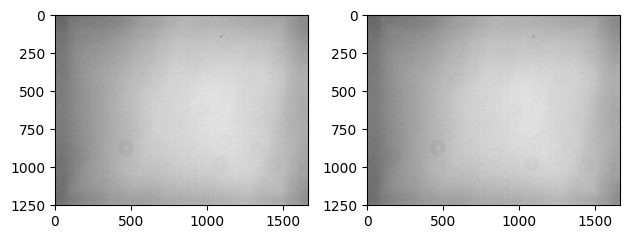

In [38]:
vmin_30, vmax_30 = zscale.get_limits(flats_pairs[30].flatten())
vmin_31, vmax_31 = zscale.get_limits(flats_pairs[31].flatten())

fig, (ax1,ax2) = plt.subplots(1,2)

ax1.imshow(flats_pairs[30], vmin=vmin_30, vmax=vmax_30, cmap='gray')
ax2.imshow(flats_pairs[31], vmin=vmin_31, vmax=vmax_31, cmap='gray')

plt.tight_layout()
plt.show()

In [40]:
# intensity
avg_30 = np.mean(flats_pairs[30])
avg_31 = np.mean(flats_pairs[31])
avg_30, avg_31

(np.float64(10081.419415045368), np.float64(10131.132572490149))

In [41]:
# noise
flat_noise_i_0_5s = np.std(flats_pairs[30]-flats_pairs[31])
flat_noise_i_0_5s

np.float64(136.08787962548524)

##### i, 1s

In [42]:
index = [i for i, filepath in enumerate(flat_pairs_files) if 'Flat_i_1s' in filepath]
index

[28, 29]

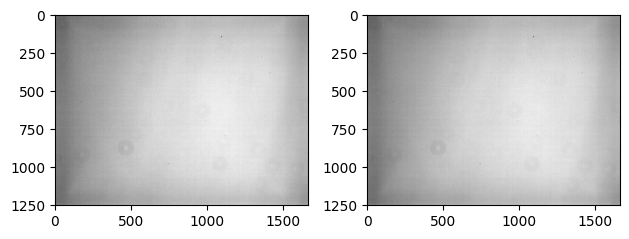

In [43]:
vmin_28, vmax_28 = zscale.get_limits(flats_pairs[28].flatten())
vmin_29, vmax_29 = zscale.get_limits(flats_pairs[29].flatten())

fig, (ax1,ax2) = plt.subplots(1,2)

ax1.imshow(flats_pairs[28], vmin=vmin_28, vmax=vmax_28, cmap='gray')
ax2.imshow(flats_pairs[29], vmin=vmin_29, vmax=vmax_29, cmap='gray')

plt.tight_layout()
plt.show()

In [44]:
# intensity
avg_28 = np.mean(flats_pairs[28])
avg_29 = np.mean(flats_pairs[29])
avg_28, avg_29

(np.float64(18039.896949006663), np.float64(18068.216075686))

In [45]:
# noise
flat_noise_i_1s = np.std(flats_pairs[28]-flats_pairs[29])
flat_noise_i_1s

np.float64(186.25215464111116)

##### i, 1.5s

In [46]:
index = [i for i, filepath in enumerate(flat_pairs_files) if 'Flat_i_1_5s' in filepath]
index

[26, 27]

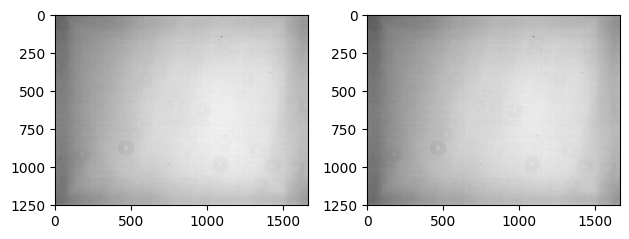

In [47]:
vmin_26, vmax_26 = zscale.get_limits(flats_pairs[26].flatten())
vmin_27, vmax_27 = zscale.get_limits(flats_pairs[27].flatten())

fig, (ax1,ax2) = plt.subplots(1,2)

ax1.imshow(flats_pairs[26], vmin=vmin_26, vmax=vmax_26, cmap='gray')
ax2.imshow(flats_pairs[27], vmin=vmin_27, vmax=vmax_27, cmap='gray')

plt.tight_layout()
plt.show()

In [48]:
# intensity
avg_26 = np.mean(flats_pairs[26])
avg_27 = np.mean(flats_pairs[27])
avg_26, avg_27

(np.float64(26015.70160263122), np.float64(26020.667760446784))

In [49]:
# noise
flat_noise_i_1_5s = np.std(flats_pairs[26]-flats_pairs[27])
flat_noise_i_1_5s

np.float64(224.5305562427229)

##### i, 2s

In [50]:
index = [i for i, filepath in enumerate(flat_pairs_files) if 'Flat_i_2s' in filepath]
index

[24, 25]

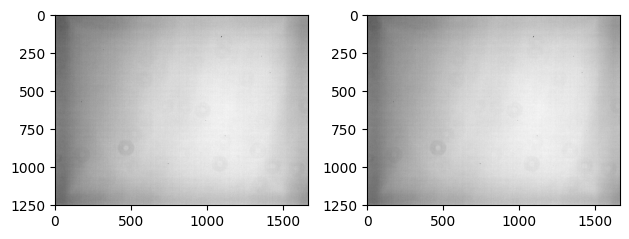

In [51]:
vmin_24, vmax_24 = zscale.get_limits(flats_pairs[24].flatten())
vmin_25, vmax_25 = zscale.get_limits(flats_pairs[25].flatten())

fig, (ax1,ax2) = plt.subplots(1,2)

ax1.imshow(flats_pairs[24], vmin=vmin_24, vmax=vmax_24, cmap='gray')
ax2.imshow(flats_pairs[25], vmin=vmin_25, vmax=vmax_25, cmap='gray')

plt.tight_layout()
plt.show()

In [52]:
# intensity
avg_24 = np.mean(flats_pairs[24])
avg_25 = np.mean(flats_pairs[25])
avg_24, avg_25

(np.float64(33871.17544028172), np.float64(33885.59736724308))

In [53]:
# noise
flat_noise_i_2s = np.std(flats_pairs[24]-flats_pairs[25])
flat_noise_i_2s

np.float64(255.7216062337257)

##### i, 2.5s

In [54]:
index = [i for i, filepath in enumerate(flat_pairs_files) if 'Flat_i_2_5s' in filepath]
index

[22, 23]

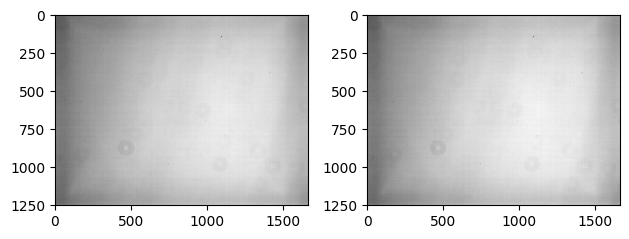

In [55]:
vmin_22, vmax_22 = zscale.get_limits(flats_pairs[22].flatten())
vmin_23, vmax_23 = zscale.get_limits(flats_pairs[23].flatten())

fig, (ax1,ax2) = plt.subplots(1,2)

ax1.imshow(flats_pairs[22], vmin=vmin_22, vmax=vmax_22, cmap='gray')
ax2.imshow(flats_pairs[23], vmin=vmin_23, vmax=vmax_23, cmap='gray')

plt.tight_layout()
plt.show()

In [56]:
# intensity
avg_22 = np.mean(flats_pairs[22])
avg_23 = np.mean(flats_pairs[23])
avg_22, avg_23

(np.float64(41531.554747761365), np.float64(41570.09752669931))

In [57]:
# noise
flat_noise_i_2_5s = np.std(flats_pairs[22]-flats_pairs[23])
flat_noise_i_2_5s

np.float64(282.0755217946718)

##### i, 3s

In [58]:
index = [i for i, filepath in enumerate(flat_pairs_files) if 'Flat_i_3s' in filepath]
index

[20, 21]

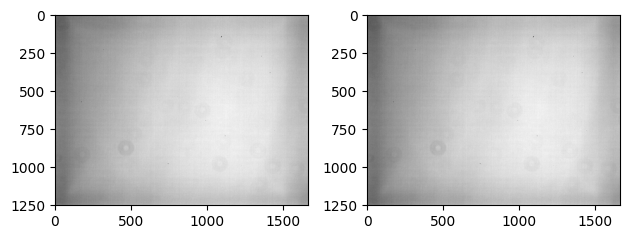

In [59]:
vmin_20, vmax_20 = zscale.get_limits(flats_pairs[20].flatten())
vmin_21, vmax_21 = zscale.get_limits(flats_pairs[21].flatten())

fig, (ax1,ax2) = plt.subplots(1,2)

ax1.imshow(flats_pairs[20], vmin=vmin_20, vmax=vmax_20, cmap='gray')
ax2.imshow(flats_pairs[21], vmin=vmin_21, vmax=vmax_21, cmap='gray')

plt.tight_layout()
plt.show()

In [60]:
# intensity
avg_20 = np.mean(flats_pairs[20])
avg_21 = np.mean(flats_pairs[21])
avg_20, avg_21

(np.float64(49219.734883837096), np.float64(49220.32419325712))

In [61]:
# noise
flat_noise_i_3s = np.std(flats_pairs[20]-flats_pairs[21])
flat_noise_i_3s

np.float64(304.79914495438845)

##### table

In [65]:
table1 = {
    'F1 avg': [avg_32, avg_30, avg_28, avg_26, avg_24, avg_22, avg_20],
    'F2 avg': [avg_33, avg_31, avg_29, avg_27, avg_25, avg_23, avg_21],
    'noise': [flat_noise_i_0_25s, flat_noise_i_0_5s, flat_noise_i_1s, flat_noise_i_1_5s,
              flat_noise_i_2s, flat_noise_i_2_5s, flat_noise_i_3s]}


results_table = pd.DataFrame(table1,
                             index=['0.25s', '0.5s', '1s', '1.5s', '2s', '2.5s', '3s'],
                             columns=['F1 avg', 'F2 avg', 'noise'])

results_table


,F1 avg,F2 avg,noise
0.25s,6057.348200,6091.762750,100.913516
0.5s,10081.419415,10131.132572,136.087880
1s,18039.896949,18068.216076,186.252155
1.5s,26015.701603,26020.667760,224.530556
2s,33871.175440,33885.597367,255.721606
2.5s,41531.554748,41570.097527,282.075522
3s,49219.734884,49220.324193,304.799145


#### g, 20s (for hot and cold pixels)

In [77]:
index = [i for i, filepath in enumerate(flat_pairs_files) if 'Flat_g_20s' in filepath]
index

[8, 9]

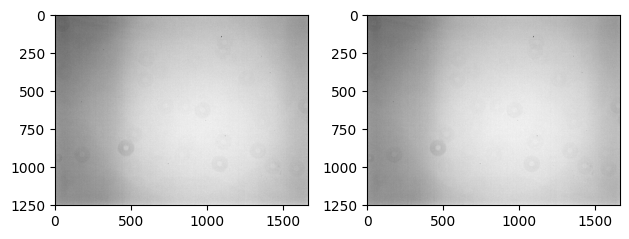

In [78]:
vmin_8, vmax_8 = zscale.get_limits(flats_pairs[8].flatten())
vmin_9, vmax_9 = zscale.get_limits(flats_pairs[9].flatten())

fig, (ax1,ax2) = plt.subplots(1,2)

ax1.imshow(flats_pairs[8], vmin=vmin_8, vmax=vmax_8, cmap='gray')
ax2.imshow(flats_pairs[9], vmin=vmin_9, vmax=vmax_9, cmap='gray')

plt.tight_layout()
plt.show()

In [79]:
avg_8 = np.mean(flats_pairs[8])
avg_8

np.float64(32397.415091476007)

### Q4.

Make a log-log plot of the observed standard deviation $\sigma_{\Delta F}$ vs the summed (bias-subtracted) intensity $\bar{F_1} + \bar{F_2} - 2\bar{B}$ . Your plot should have one datapoint for each integration time. The theoretical curve for the data follows the shape:

$$\sigma(I[e^-]) = \sqrt{I+2RN^2[e^-]} = \sqrt{I+2\sigma_B^2[e^-]}$$

For a CCD with gain setting $g$, intensity $I$ recorded in ADUs will be . The equation above can be rewritten as:

$$\sigma(I[ADU]) = \sqrt{\frac{I[ADU]}{g} + 2\sigma_B^2[ADU]}$$

Using this equation and your earlier measurement of the readnoise, determine a value of $g$ that fits your data nicely (either by eyeball or performing an actual fit).

In [63]:
# i filter
noise = [flat_noise_i_0_25s,
         flat_noise_i_0_5s,
         flat_noise_i_1s,
         flat_noise_i_1_5s,
         flat_noise_i_2s,
         flat_noise_i_2_5s,
         flat_noise_i_3s]

intensity = [avg_32+avg_33-2*avg_bias,
             avg_30+avg_31-2*avg_bias,
             avg_28+avg_29-2*avg_bias,
             avg_26+avg_27-2*avg_bias,
             avg_24+avg_25-2*avg_bias,
             avg_22+avg_23-2*avg_bias,
             avg_20+avg_21-2*avg_bias]

labels = ['0.25s', '0.5s', '1s', '1.5s', '2s', '2.5s', '3s']

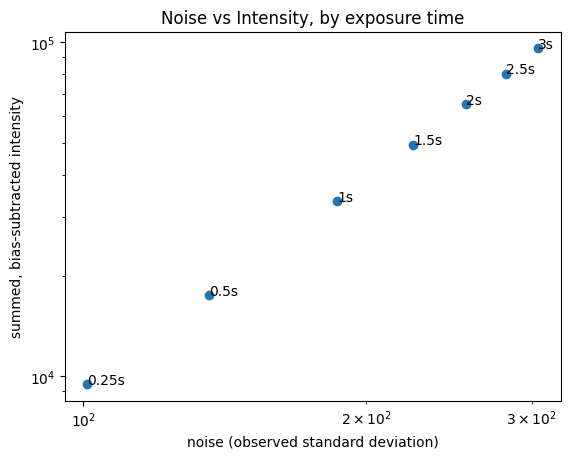

In [66]:
plt.loglog(noise, intensity, 'o')

plt.xlabel('noise (observed standard deviation)')
plt.ylabel('summed, bias-subtracted intensity')
plt.title('Noise vs Intensity, by exposure time')

for i, txt in enumerate(labels):
    plt.annotate(txt, (noise[i], intensity[i]))

plt.show()

### Q5.

For each exposure time, compute the gain of your detector using this equation:

$$g = \frac{(\bar{F_1} + \bar{F_2}-2\bar{B})}{(\sigma_{\Delta_F}^2 - 2\sigma_B^2)}$$

As above, $g$ has units of $e^-$/ADU. Are the gain values you get consistent across all exposure times?

#### i, 0.25s

In [67]:
g_0_25s = (avg_32+avg_33-2*avg_bias)/(flat_noise_i_0_25s**2-2*rn**2)
g_0_25s

np.float64(0.958541087029556)

#### i, 0.5s

In [68]:
g_0_5s = (avg_30+avg_31-2*avg_bias)/(flat_noise_i_0_5s**2-2*rn**2)
g_0_5s

np.float64(0.9625360402496237)

#### i, 1s

In [69]:
g_1s = (avg_28+avg_29-2*avg_bias)/(flat_noise_i_1s**2-2*rn**2)
g_1s

np.float64(0.9721797551726007)

#### i, 1.5s

In [70]:
g_1_5s = (avg_26+avg_27-2*avg_bias)/(flat_noise_i_1_5s**2-2*rn**2)
g_1_5s

np.float64(0.984989146867048)

#### i, 2s

In [71]:
g_2s = (avg_24+avg_25-2*avg_bias)/(flat_noise_i_2s**2-2*rn**2)
g_2s

np.float64(0.9998304504904293)

#### i, 2.5s

In [72]:
g_2_5s = (avg_22+avg_23-2*avg_bias)/(flat_noise_i_2_5s**2-2*rn**2)
g_2_5s

np.float64(1.0146488538375675)

#### i, 3s

In [73]:
g_3s = (avg_20+avg_21-2*avg_bias)/(flat_noise_i_3s**2-2*rn**2)
g_3s

np.float64(1.0341692233540383)

#### table 2

In [75]:
table2 = {
    'gain': [g_0_25s, g_0_5s, g_1s, g_1_5s, g_2s, g_2_5s, g_3s]}

table_2 = pd.DataFrame(table2,
                       index=['0.25s', '0.5s', '1s', '1.5s', '2s', '2.5s', '3s'],
                       columns=['gain'])

table_2

,gain
0.25s,0.958541
0.5s,0.962536
1s,0.972180
1.5s,0.984989
2s,0.999830
2.5s,1.014649
3s,1.034169


## describe CCD's flat-field pattern and cosmetics (Q6-Q8)

### Q6.

Use your highest signal-to-noise flat-field image (across all exposure times) to derive the number of hot and cold pixels, defined as deviating from the overall sensitivity by more than 20%.

In [84]:
# i, 3s
# np.sum(flats_pairs[20]>avg_20*1.2)
np.sum(flats_pairs[20]>(avg_20-avg_bias)*1.2)

np.int64(0)

In [81]:
# g, 20s
np.sum(flats_pairs[8]>avg_8*1.2)

np.int64(38)

### Q7.

Describe the overall flat-field cosmetics. Do you notice any peculiar features, or regions of the detector with depressed sensitivity (you may want to avoid those when taking actual on-sky data)?

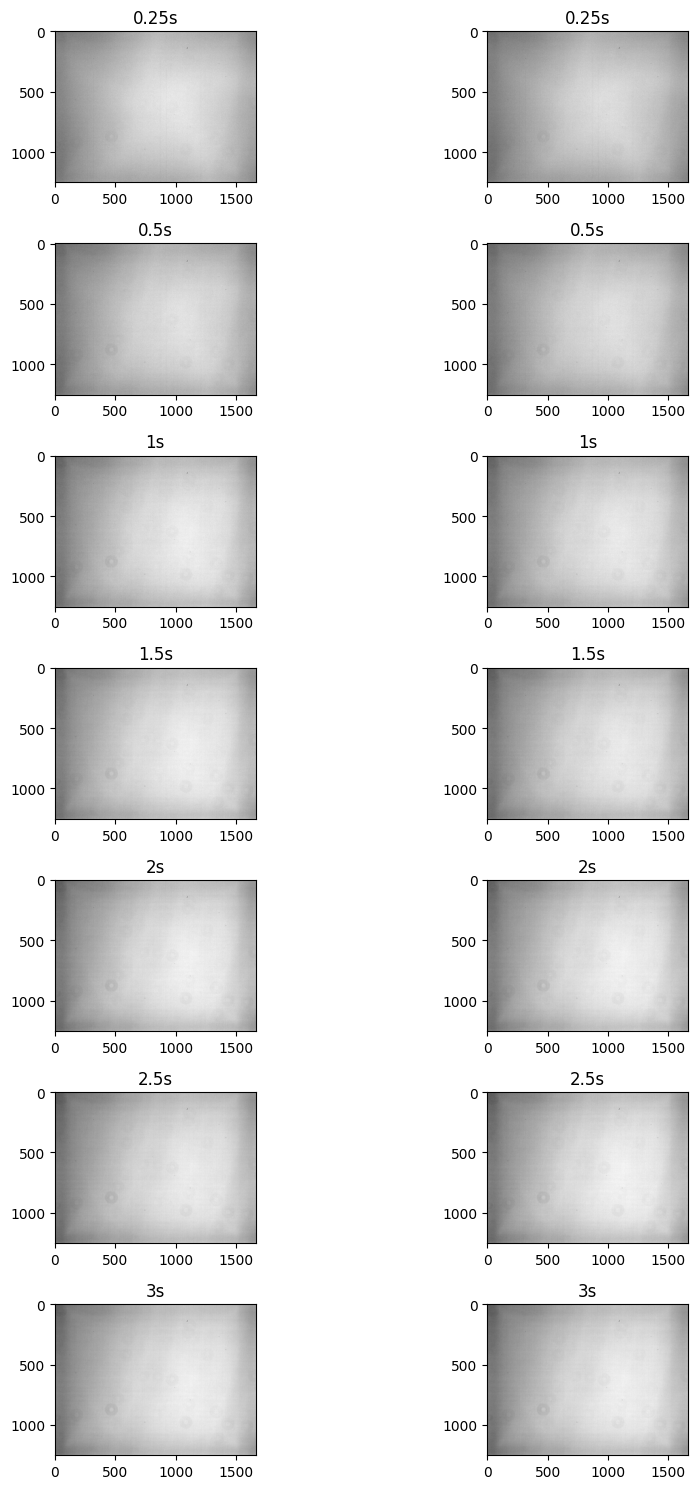

In [90]:
fig, axes = plt.subplots(7, 2, figsize=(10, 15))
axes = axes.flatten()

# 0.25s
axes[0].imshow(flats_pairs[32], vmin=vmin_32, vmax=vmax_32, cmap='gray')
axes[0].set_title('0.25s')
axes[1].imshow(flats_pairs[33], vmin=vmin_33, vmax=vmax_33, cmap='gray')
axes[1].set_title('0.25s')
# 0.5s
axes[2].imshow(flats_pairs[30], vmin=vmin_30, vmax=vmax_30, cmap='gray')
axes[2].set_title('0.5s')
axes[3].imshow(flats_pairs[31], vmin=vmin_31, vmax=vmax_31, cmap='gray')
axes[3].set_title('0.5s')
# 1s
axes[4].imshow(flats_pairs[28], vmin=vmin_28, vmax=vmax_28, cmap='gray')
axes[4].set_title('1s')
axes[5].imshow(flats_pairs[29], vmin=vmin_29, vmax=vmax_29, cmap='gray')
axes[5].set_title('1s')
# 1.5s
axes[6].imshow(flats_pairs[26], vmin=vmin_26, vmax=vmax_26, cmap='gray')
axes[6].set_title('1.5s')
axes[7].imshow(flats_pairs[27], vmin=vmin_27, vmax=vmax_27, cmap='gray')
axes[7].set_title('1.5s')
# 2s
axes[8].imshow(flats_pairs[24], vmin=vmin_24, vmax=vmax_24, cmap='gray')
axes[8].set_title('2s')
axes[9].imshow(flats_pairs[25], vmin=vmin_25, vmax=vmax_25, cmap='gray')
axes[9].set_title('2s')
# 2.5s
axes[10].imshow(flats_pairs[22], vmin=vmin_22, vmax=vmax_22, cmap='gray')
axes[10].set_title('2.5s')
axes[11].imshow(flats_pairs[23], vmin=vmin_23, vmax=vmax_23, cmap='gray')
axes[11].set_title('2.5s')
# 3s
axes[12].imshow(flats_pairs[20], vmin=vmin_20, vmax=vmax_20, cmap='gray')
axes[12].set_title('3s')
axes[13].imshow(flats_pairs[21], vmin=vmin_21, vmax=vmax_21, cmap='gray')
axes[13].set_title('3s')

plt.tight_layout()
plt.show()

### Q8.

Compare your flat-fields from the different bandpasses. What is the main source of contamination: bandpass filters or the detector?

In [94]:
index = [i for i, filepath in enumerate(flat_files) if '0_1s' in filepath]
index

[0, 21, 22, 23, 24, 25]

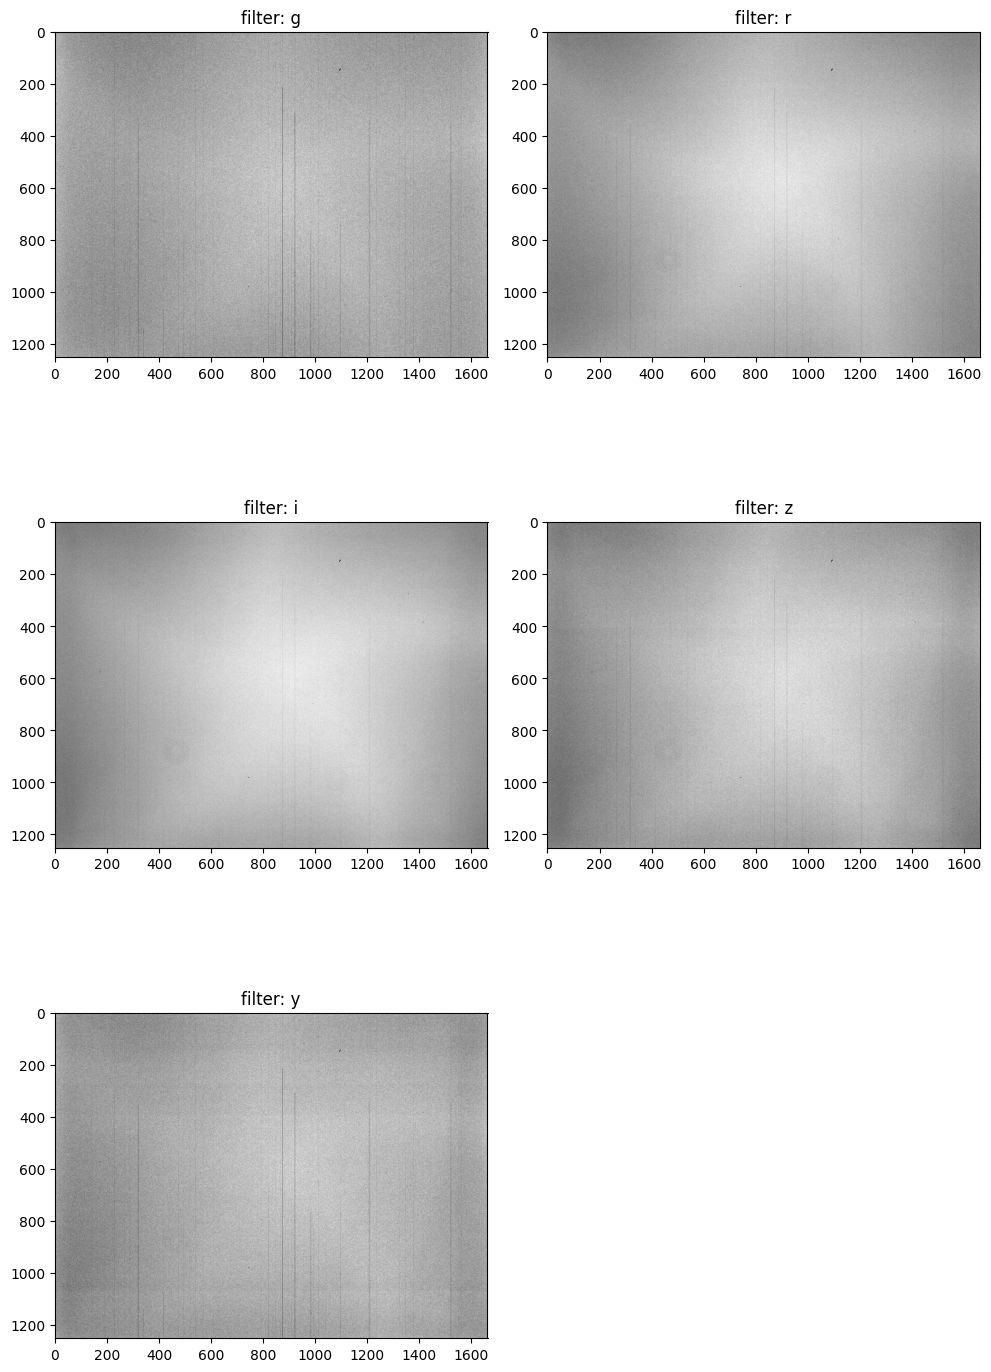

In [97]:
vmin_21, vmax_21 = zscale.get_limits(flats[21].flatten())
vmin_22, vmax_22 = zscale.get_limits(flats[22].flatten())
vmin_23, vmax_23 = zscale.get_limits(flats[23].flatten())
vmin_24, vmax_24 = zscale.get_limits(flats[24].flatten())
vmin_25, vmax_25 = zscale.get_limits(flats[25].flatten())

fig, axes = plt.subplots(3, 2, figsize=(10, 15))
axes = axes.flatten()

axes[0].imshow(flats[21], vmin=vmin_21, vmax=vmax_21, cmap='gray')
axes[0].set_title('filter: g')
axes[1].imshow(flats[22], vmin=vmin_22, vmax=vmax_22, cmap='gray')
axes[1].set_title('filter: r')
axes[2].imshow(flats[23], vmin=vmin_23, vmax=vmax_23, cmap='gray')
axes[2].set_title('filter: i')
axes[3].imshow(flats[24], vmin=vmin_24, vmax=vmax_24, cmap='gray')
axes[3].set_title('filter: z')
axes[4].imshow(flats[25], vmin=vmin_25, vmax=vmax_25, cmap='gray')
axes[4].set_title('filter: y')

for j in range(5, 6):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Q9.


for small $\delta$, $tan(\delta) = \delta$